In [4]:
# Computer Vision Course (CSE 40535/60535)
# University of Notre Dame, Fall 2024
# ________________________________________________________________
# Adam Czajka, Jin Huang, September 2017 - 2024

import cv2
import numpy as np
from skimage import measure
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

### Read our input image ###

In [5]:
# Read the image into grayscale
sample = cv2.imread('breakfast.png')

# Alertnatively, you can connect to your Google Drive and read the image from there
# from google.colab import drive
# drive.mount('/content/drive')
# Your files stored in your Google Drive are now available at /content/drive/MyDrive/
# in this entire Colab notebook.

### Convert our image to grayscale and HSV images ###

Grey scale image


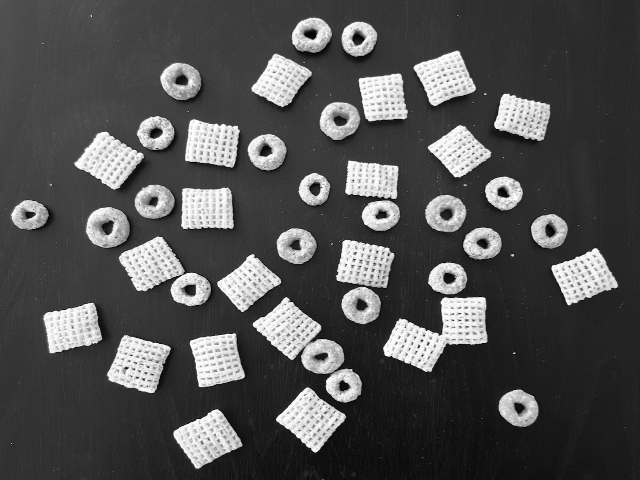

H channel of the image


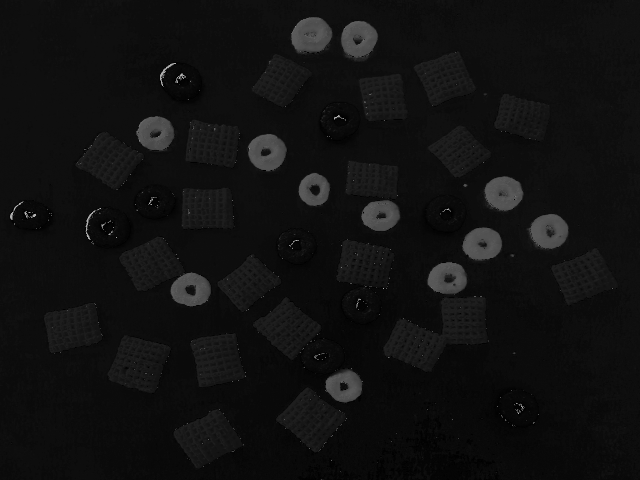

In [6]:
# Convert the original image to grayscale
sample_grey = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

# Show the grey scale image
sample_small = cv2.resize(sample_grey, (640, 480))
print('Grey scale image')
cv2_imshow(sample_small)

# Convert the original image to HSV
# and take H channel for further calculations
sample_hsv = cv2.cvtColor(sample, cv2.COLOR_BGR2HSV)
sample_h = sample_hsv[:, :, 0]

# Uncomment this to show the H channel of the image
sample_small = cv2.resize(sample_h, (640, 480))
print('H channel of the image')
cv2_imshow(sample_small)

### Pre-process your images ###

Image after Otsus thresholding


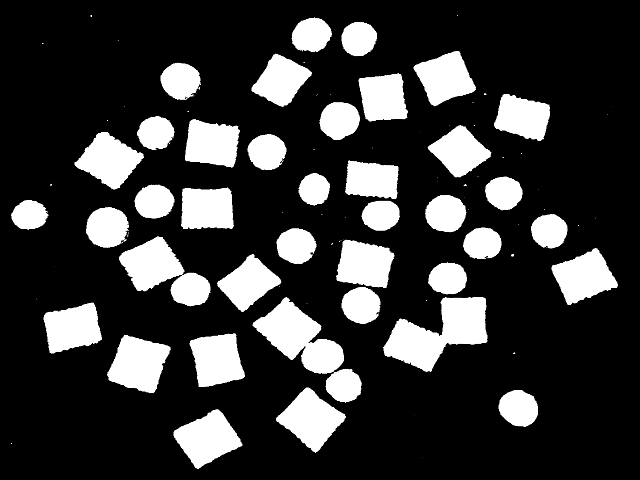

Image after morphological transformation [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


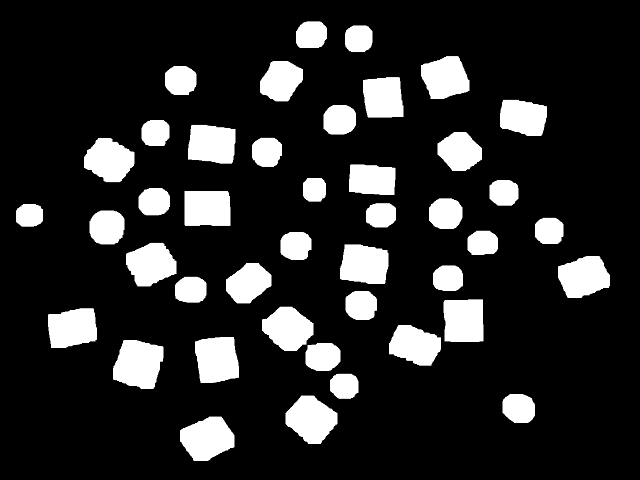

In [7]:
# Binarize the image using Otsu's method
ret1, binary_image = cv2.threshold(src=sample_grey, thresh=0, maxval=255, type=cv2.THRESH_BINARY+cv2.THRESH_OTSU)

im_floodfill = binary_image.copy()
h, w = binary_image.shape[:2]
mask = np.zeros((h+2,w+2), np.uint8)
cv2.floodFill(im_floodfill, mask, (0, 0), 255)
im_floodfill_inv = cv2.bitwise_not(im_floodfill)
binary_image = binary_image | im_floodfill_inv

# Uncomment this to show image after Otsu''s thresholding
sample_small = cv2.resize(src=binary_image, dsize=(640, 480))
print('Image after Otsu''s thresholding')
cv2_imshow(sample_small)

################################################################################
# *** TASK *** It's a good place to apply morphological operations to the "binary_image"

kernel = np.ones((5,5), np.uint8)

# First erode slightly to break thin connections
eroded = cv2.erode(binary_image, kernel, iterations=8)

# Then dilate back
sample_res = cv2.dilate(eroded, kernel, iterations=6)


# Uncomment this to show image after morphological transformation
sample_small = cv2.resize(sample_res, (640, 480))
print('Image after morphological transformation',sample_small)
cv2_imshow(sample_small)




### Find the objects and extract their features ###

In [8]:
# Find connected pixels and compose them into objects
labels = measure.label(sample_res)

# Calculate features for each object; since we want to differentiate
# between circular and square shapes, the major and minor axes may be less helpful
# so think what other features could be useful; we will use also the centroid
# to annotate the final result
properties = measure.regionprops(labels)


################################################################################
# *** TASK *** Calculate features for each object:
# - some geometrical feature 1 (dimension 1)
# - some intensity/color-based feature 2 (dimension 2)

# translating our image to the HSV color space:
sample_hsv = cv2.cvtColor(sample, cv2.COLOR_BGR2HSV)
sample_h = sample_hsv[:, :, 0]


features = np.zeros((len(properties), 2))

for i in range(len(properties)):
  # geometric feature
  features[i, 1] = properties[i].perimeter

  # mask for this object
  object_mask = (labels == properties[i].label)

  # compute mean hue only on object pixels
  features[i, 0] = np.mean(sample_h[object_mask])




### We have features. Time to classify! ###

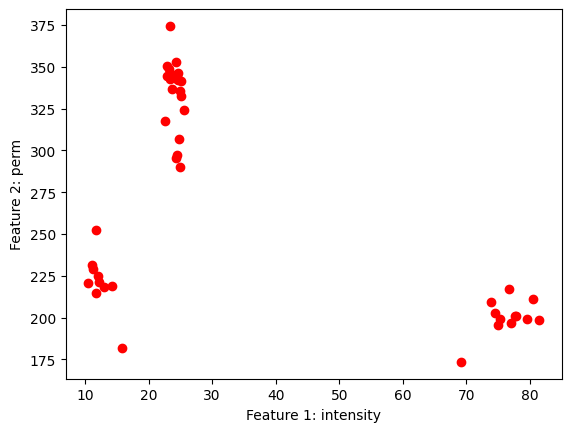

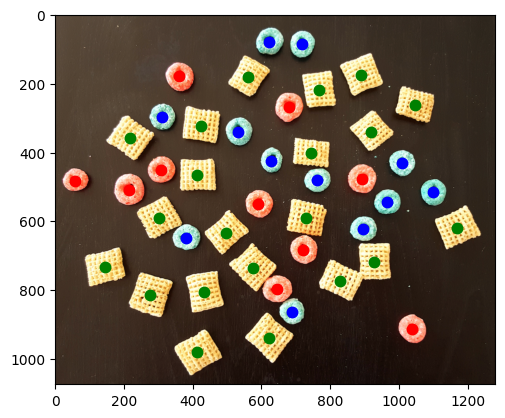

I found 21 squares, 12 blue donuts, and 10 red donuts.


In [9]:
################################################################################
# *** TASK *** Show our objects in the feature space

plt.plot(features[:, 0],features[:, 1], 'ro')
plt.xlabel('Feature 1: intensity')
plt.ylabel('Feature 2: perm')
plt.show()


################################################################################
# *** TASK *** Choose the threshold
thrF1 = 50
thrF2 = 275


# Count and display the objects
squares = 0
blue_circles = 0
red_circles = 0

fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))


################################################################################
# *** TASK *** Code your classification here (using calculated features):
for i in range(0, len(properties)):
  if (features[i, 1] > thrF2):
    squares = squares + 1
    ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.g', markersize=15)

  elif (features[i, 0] > thrF1):
    blue_circles = blue_circles + 1
    ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.b', markersize=15)

  else:
    red_circles = red_circles + 1
    ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.r', markersize=15)

plt.show()

# That's all for Task 1! Let's display the result:
print("I found %d squares, %d blue donuts, and %d red donuts." % (squares, blue_circles, red_circles))

### Now code the solution for Task 2 (use texture feature instead of one of the previous two features) ###

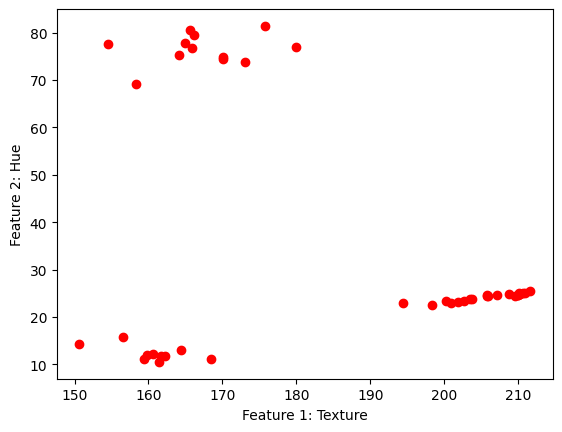

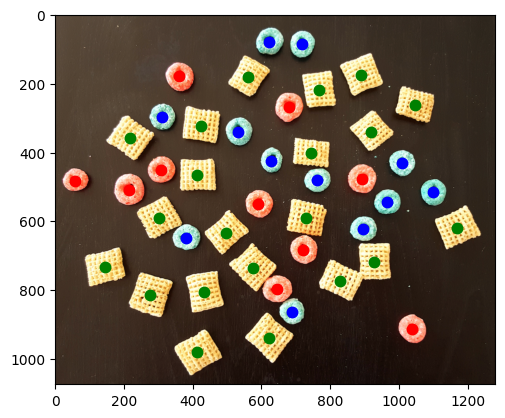

I found 21 squares, 12 blue donuts, and 10 red donuts.


In [11]:
### Improved Task 2 code with multi-orientation Gabor filter
sample = cv2.imread('breakfast.png')
# Convert the original image to grayscale
sample_grey = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

ksize = 13
sigma = 2.0
theta = 0.0
lbd = 10.0
gamma = 0.5
psi = 0.0

gabor_kernel = cv2.getGaborKernel(
    (ksize, ksize), sigma, theta, lbd, gamma, psi, ktype=cv2.CV_32F
)
res1 = cv2.filter2D(sample_grey, cv2.CV_64F, gabor_kernel)
res3 = cv2.normalize(np.abs(res1), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)



################################################################################
# *** TASK *** Calculate features for each object:
# - some geometrical feature 1 (dimension 1)
# - some intensity/color-based feature 2 (dimension 2)


features = np.zeros((len(properties), 2))
for i in range(0, len(properties)):
    min_row, min_col, max_row, max_col = properties[i].bbox
    single_object_hue = sample_h[min_row:max_row,min_col:max_col]
    single_text = res3[min_row:max_row, min_col:max_col]
    obj_mask = labels[min_row:max_row, min_col:max_col] == properties[i].label

    features[i, 1] = np.mean(single_object_hue[obj_mask])
    features[i, 0] = np.mean(single_text[obj_mask])

  ################################################################################
# *** TASK *** Show our objects in the feature space

plt.plot(features[:, 0],features[:, 1], 'ro')
plt.xlabel('Feature 1: Texture')
plt.ylabel('Feature 2: Hue')
plt.show()


################################################################################
# *** TASK *** Choose the threshold
thrF1 = 185
thrF2 = 40


# Count and display the objects
squares = 0
blue_circles = 0
red_circles = 0

fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))


################################################################################
# *** TASK *** Code your classification here (using calculated features):
for i in range(0, len(properties)):
    if (features[i, 0] > thrF1 and features[i, 1] < thrF2):
       squares = squares + 1
       ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.g', markersize=15)

    if (features[i, 0] < thrF1 and features[i, 1] > thrF2):
       blue_circles = blue_circles + 1
       ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.b', markersize=15)

    if (features[i, 0] < thrF1 and features[i, 1] < thrF2):
       red_circles = red_circles + 1
       ax.plot(np.round(properties[i].centroid[1]), np.round(properties[i].centroid[0]), '.r', markersize=15)

plt.show()

print("I found %d squares, %d blue donuts, and %d red donuts." % (squares, blue_circles, red_circles))